# **🎬 IMDB Movie Review Sentiment Analysis**
This project aims to perform a descriptive sentiment analysis on 50000 movie review data from IMDB to understand the linguistic patterns of a positive or negative film review.

## **Objectives**
1. Identify the most common **words** and **phrases** present in positive or negative reviews. 
2. Analyze the correlation between **review length and sentiment**. 

## **Key Takeaway/Executive Summary**
Positive reviews are **descriptive** and focus more on **storytelling and emotions** while negative reviews are **evaluative** and critical, focusing more on **production and quality**.

## **Limitations**
This project will not use any **advanced NLP or ML** algorithms. This project is a data analysis exercise, so only descriptive analysis is performed.

## **Data Structure**

| Review | Sentiment | 
|---|---|
| Complete paragraphs of user-written movie reviews | Positive/Negative |

## **1. Import Library and Dataset**

In [ ]:
#import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from string import punctuation

#stop words
import nltk
from nltk.corpus import stopwords

#stemmer
from nltk.stem import SnowballStemmer

#lemmitizer
from nltk.stem import WordNetLemmatizer

#wordcloud
from PIL import Image
from wordcloud import WordCloud

#phrases/n-grams
from sklearn.feature_extraction.text import CountVectorizer

#bigquery
from google.oauth2 import service_account
import pandas_gbq

#spacy tokenizer (not used)
import spacy

In [4]:
dir = r"C:\Users\mariq\Documents\2. KERJA\Purwadika\Module 2\Portofolio 2\IMDB Dataset.csv"
df = pd.read_csv(dir)

In [5]:
#INSPECT DATASET
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## **2. Exploratory Data Analysis**
Brief EDA for sentiments and review length.

In [6]:
#CHECKING SENTIMENT DISTRIBUTION
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [7]:
df.describe(include="all")

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [8]:
#ADDING TEXT LENGTH COLUMN, and DESCRIBING IT
df['text_length'] = df['review'].apply(lambda x: len(x.split()))
df['text_length'].describe()

count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: text_length, dtype: float64

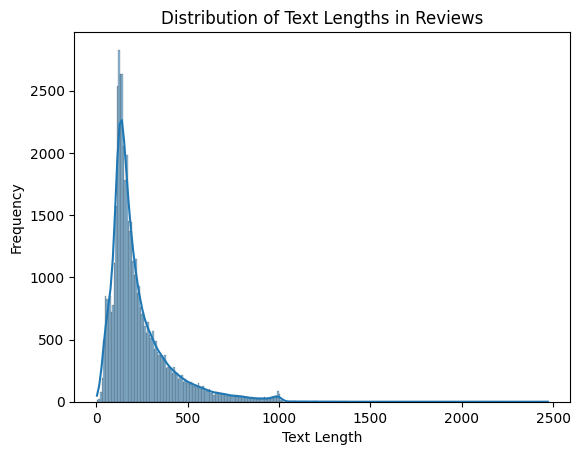

In [9]:
sns.histplot(df['text_length'], kde=True)
plt.title('Distribution of Text Lengths in Reviews')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

## **3. Text Preprocessing 1**

Method :
1. Delete HTML Tags and convert to lower case
2. Contraction
3. Remove or convert number into text
4. Remove Punctuation
5. Remove white spaces
6. Remove Stop Words

### **3.1. Converting to Lower Case and Removing HTML Tags**

In [10]:
def clean_text(text):
    text = text.lower()                      #lowercase
    text = re.sub(r'<.*?>', '', text)        #delete HTML tags 
    text = re.sub(r'[-]',' ', text)          #replace hypens with space
    return text

In [11]:
#sanity check contraction
test = "LeBron <i> is the Greatest of All-time."

test = clean_text(test)

print(test)

lebron  is the greatest of all time.


### **3.2. Contraction**
Defining words or combination of words that are shortened.

In [12]:
contractions_dict = {
"ain't": "am not",
"aren't": "are not",
"can't": "cannot",
"can't've": "cannot have",
"'cause": "because",
"could've": "could have",
"couldn't": "could not",
"couldn't've": "could not have",
"didn't": "did not",
"doesn't": "does not",
"don't": "do not",
"hadn't": "had not",
"hadn't've": "had not have",
"hasn't": "has not",
"haven't": "have not",
"he'd": "he had",
"he'd've": "he would have",
"he'll": "he will",
"he'll've": "he will have",
"he's": "he is",
"how'd": "how did",
"how'd'y": "how do you",
"how'll": "how wix`ll",
"how's": "how is",
"I'd": "I had",
"I'd've": "I would have",
"I'll": "I will",
"I'll've": "I will have",
"I'm": "I am",
"I've": "I have",
"isn't": "is not",
"it'd": "it had",
"it'd've": "it would have",
"it'll": "it will",
"it'll've": "iit will have",
"it's": "it is",
"let's": "let us",
"ma'am": "madam",
"mayn't": "may not",
"might've": "might have",
"mightn't": "might not",
"mightn't've": "might not have",
"must've": "must have",
"mustn't": "must not",
"mustn't've": "must not have",
"needn't": "need not",
"needn't've": "need not have",
"o'clock": "of the clock",
"oughtn't": "ought not",
"oughtn't've": "ought not have",
"shan't": "shall not",
"sha'n't": "shall not",
"shan't've": "shall not have",
"she'd": "she had",
"she'd've": "she would have",
"she'll": "she will",
"she'll've": "she will have",
"she's": "she is",
"should've": "should have",
"shouldn't": "should not",
"shouldn't've": "should not have",
"so've": "so have",
"so's": "so is",
"that'd": "that had",
"that'd've": "that would have",
"that's": "that is",
"there'd": "there had",
"there'd've": "there would have",
"there's": "there is",
"they'd": "they had",
"they'd've": "they would have",
"they'll": "they will",
"they'll've": "they will have",
"they're": "they are",
"they've": "they have",
"to've": "to have",
"wasn't": "was not",
"we'd": "we had",
"we'd've": "we would have",
"we'll": "we will",
"we'll've": "we will have",
"we're": "we are",
"we've": "we have",
"weren't": "were not",
"what'll": "what will",
"what'll've": "what will have",
"what're": "what are",
"what's": "what is",
"what've": "what have",
"when's": "when is",
"when've": "when have",
"where'd": "where did",
"where's": "where is",
"where've": "where have",
"who'll": "who will",
"who'll've": "who will have",
"who's": "who is",
"who've": "who have",
"why's": "why is",
"why've": "why have",
"will've": "will have",
"won't": "will not",
"won't've": "will not have",
"would've": "would have",
"wouldn't": "would not",
"wouldn't've": "would not have",
"y'all": "you all",
"y'all'd": "you all would",
"y'all'd've": "you all would have",
"y'all're": "you all are",
"y'all've": "you all have",
"you'd": "you had",
"you'd've": "you would have",
"you'll": "you will",
"you'll've": "you will have",
"you're": "you are",
"you've": "you have"
}

#normalize non-standard apostrophe to the standard one.
def normalize_apostrophes(text): 
    return re.sub(r"[’‘`´]", "'", text)

#builds a regex pattern from contraction keys (by length descending)
def build_contraction_pattern(contractions_dict):
    keys = sorted(contractions_dict.keys(), key=len, reverse=True)
    pattern = r"\b(" + "|".join(re.escape(k) for k in keys) + r")\b"
    return re.compile(pattern, flags=re.IGNORECASE)

# precompile
contraction_pattern = build_contraction_pattern(contractions_dict)

def expand_contractions(text, contractions_dict=contractions_dict):
    text = normalize_apostrophes(text)

    def replace(match):
        match_text = match.group(0)
        # Try exact and lowercase keys
        expanded = contractions_dict.get(match_text)
        if not expanded:
            expanded = contractions_dict.get(match_text.lower())
        # Fallback if missing
        return expanded if expanded else match_text

    expanded_text = contraction_pattern.sub(replace, text)
    expanded_text = re.sub(r"\s+", " ", expanded_text).strip()
    return expanded_text

def main_contraction(text):
    return expand_contractions(text)

### OBSOLETE ORIGINAL VERSION
# def expand_contractions(text, contractions_dict):
#     contractions_pattern = re.compile('({})'.format('|'.join(contractions_dict.keys())),
#                                       flags=re.IGNORECASE | re.DOTALL)

#     def expand_match(contraction):
#         match = contraction.group(0)
#         first_char = match[0]
#         expanded_contraction = contractions_dict.get(match) \
#             if contractions_dict.get(match) \
#             else contractions_dict.get(match.lower())
#         expanded_contraction = expanded_contraction
#         return expanded_contraction

#     expanded_text = contractions_pattern.sub(expand_match, text)
#     expanded_text = re.sub("'", "", expanded_text)
#     return expanded_text

# def main_contraction(text):
#     text = expand_contractions(text, contractions_dict)
#     return text

In [13]:
#sanity check contraction
test = [
    "You mustn't've known what'll happen next",
    "They're not what you'd expect.",
    "It’s something you shouldn’t’ve missed." #non-standard apostrophe
]

for t in test:
    print(main_contraction(t))

You must not have known what will happen next
they are not what you had expect.
it is something you should not have missed.


### **3.3. Remove or Convert Number into Text**
Unimportant in the context of this text analysis.

In [14]:
def remove_numbers(text):
    output = ''.join(c for c in text if not c.isdigit())
    return output

In [16]:
#sanity check remove number
test = "i have a 2012 Ford Bronco"

test = remove_numbers(test)

print(test)

i have a  Ford Bronco


### **3.4. Remove Punctuation**
Contextually remove punctuations.

In [17]:
def remove_punctuation(text):
    text = re.sub(r'[{}]+'.format(re.escape(punctuation)), ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [18]:
#sanity check punctuation
test = [
    "decently.the", #one of an error token
    "you sir, are a fool.",
    "certainly...it is incorrect"
]

for t in test:
    print(remove_punctuation(t))

decently the
you sir are a fool
certainly it is incorrect


### **3.5. Remove Whitespaces**
Delete leading/trailing spaces that are empty.

In [19]:
def to_strip(text):
    return " ".join(text.split())

In [20]:
#sanity check whitespace
test = "aw    man"
test = to_strip(test)
print(test)

aw man


### **3.6. Remove Stop Words**
Remove common words that does not add any information.

In [21]:
#download Natural Language Toolkit
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mariq\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mariq\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\mariq\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [22]:
#show stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [23]:
def remove_stopwords(sentence):
    stop_words = stopwords.words('english')
    return ' '.join([w for w in nltk.word_tokenize(sentence) if not w in stop_words])

In [24]:
#sanity check stopwords
test = "we won't leave you with yourself"

test = main_contraction(test) #to contract "won't -> "will not""
test = remove_stopwords(test)

print(test)

leave


## **4. Combine Preprocessing Methods**
Show each preprocessing step into their own column for easier analysis.

In [25]:
pd.options.display.max_colwidth = None

In [27]:
df['review_prep1'] = df['review'].apply(clean_text)
df['review_prep2'] = df['review_prep1'].apply(main_contraction)
df['review_prep3'] = df['review_prep2'].apply(remove_numbers)
df['review_prep4'] = df['review_prep3'].apply(remove_punctuation)
df['review_prep5'] = df['review_prep4'].apply(to_strip)
df['review_prep6'] = df['review_prep5'].apply(remove_stopwords)
df.head(2)

,review,sentiment,text_length,review_prep1,review_prep2,review_prep3,review_prep4,review_prep5,review_prep6
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.",positive,307,"one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.i would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. forget pretty pictures painted for mainstream audiences, forget charm, forget romance...oz doesn't mess around. the first episode i ever saw struck me as so nasty it was surreal, i couldn't say i was ready for it, but as i watched more, i developed a taste for oz, and got accustomed to the high levels of graphic violence. not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) watching oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.","one of the other reviewers has mentioned that after watching just 1 oz episode you will be hooked. they are right, as this is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with rega

## **5. Text Preprocessing 2**
**Lemmatization** is used instead of stemming to maintain the subjectivity nature of reviews that would otherwise be removed when words are stripped to their root form. Instead, stemming is better utilized for training language models.

### **5.1. Lemmatization**

Transform words into their dictionary base/root form.

In [28]:
nltk.download('wordnet')

wordnet_lemmatizer = WordNetLemmatizer()

def lemmatize(text):
    lemmatized_word = [wordnet_lemmatizer.lemmatize(word)for sent in nltk.sent_tokenize(text)for word in nltk.word_tokenize(sent)]
    return " ".join(lemmatized_word)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mariq\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [29]:
#apply lemmatization
df['review_lemmatized'] = df['review_prep6'].apply(lemmatize)

df[['review_lemmatized']].head()

,review_lemmatized
0,one reviewer mentioned watching oz episode hooked right exactly happened first thing struck oz brutality unflinching scene violence set right word go trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use word called oz nickname given oswald maximum security state penitentary focus mainly emerald city experimental section prison cell glass front face inwards privacy high agenda em city home many aryan muslim gangsta latino christian italian irish scuffle death stare dodgy dealing shady agreement never far away would say main appeal show due fact go show would dare forget pretty picture painted mainstream audience forget charm forget romance oz mess around first episode ever saw struck nasty surreal could say ready watched developed taste oz got accustomed high level graphic violence violence injustice crooked guard sold nickel inmate kill order get away well mannered middle class inmate turned prison bitch due lack street skill prison experience watching oz may become comfortable uncomfortable viewing thats get touch darker side
1,wonderful little production filming technique unassuming old time bbc fashion give comforting sometimes discomforting sense realism entire piece actor extremely well chosen michael sheen got polari voice pat truly see seamless editing guided reference williams diary entry well worth watching terrificly written performed piece masterful production one great master comedy life realism really come home little thing fantasy guard rather use traditional dream technique remains solid disappears play knowledge sens particularly scene concerning orton halliwell set particularly flat halliwell mural decorating every surface terribly well done
2,thought wonderful way spend time hot summer weekend sitting air conditioned theater watching light hearted comedy plot simplistic dialogue witty character likable even well bread suspected serial killer may disappointed realize match point risk addiction thought proof woody allen still fully control style many u grown love laughed one woody comedy year dare say decade never impressed scarlet johanson managed tone sexy image jumped right average spirited young woman may crown jewel career wittier devil wear prada interesting superman great comedy go see friend
3,basically family little boy jake think zombie closet parent fighting time movie slower soap opera suddenly jake decides become rambo kill zombie ok first going make film must decide thriller drama drama movie watchable parent divorcing arguing like real life jake closet totally ruin film expected see boogeyman similar movie instead watched drama meaningless thriller spot well playing parent descent dialog shot jake ignore
4,petter mattei love time money visually stunning film watch mr mattei offer u vivid portrait human relation movie seems telling u money power success people different situation encounter variation arthur schnitzler play theme director transfer action present time new york different character meet connect one connected one way another next person one seems know previous point contact stylishly film sophisticated luxurious look taken see people live world live habitat thing one get soul picture different stage loneliness one inhabits big city exactly best place human relation find sincere fulfillment one discerns case people encounter acting good mr mattei direction steve buscemi rosario dawson carol kane michael imperioli adrian grenier rest talented cast make character come alive wish mr mattei good luck await anxiously next work


## **6. Word Frequency Analysis**
Identifying most common words present in both sentiments.

### **6.1. Tokenization**
Breaks text into words then extract the frequency of each unique words.

In [30]:
def kamus(check):
    check = check.str.extractall('([a-zA_Z]+)') #tokenize/extract each unique character
    check.columns = ['check']
    b = check.reset_index(drop=True)
    check = b['check'].value_counts()

    kamus = {'kata':check.index,'freq':check.values}
    kamus = pd.DataFrame(kamus)
    kamus.index = kamus['kata']
    kamus.drop('kata', axis = 1, inplace = True)
    kamus.sort_values('freq',ascending=False,inplace=True)

    return kamus

In [31]:
kamus_unclean = kamus(df['review_lemmatized'])

kamus_unclean

,freq
kata,
movie,103234
film,93428
one,55430
like,41120
time,31454
...,...
mullah,1
homie,1
avin,1


### **6.2. Visualize Word Frequency**

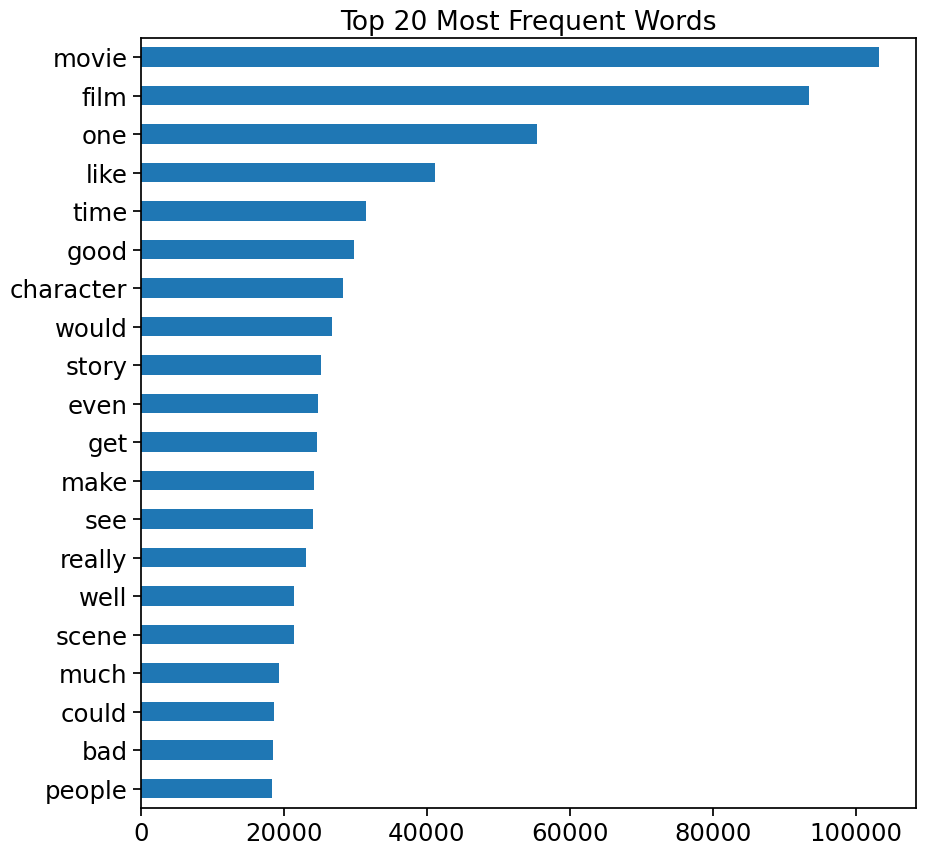

In [82]:
sns.set_context(context = 'notebook', font_scale = 1.6)
kamus_unclean[:20].iloc[::-1].plot(kind = 'barh',figsize = (10,10), legend=False)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("")
plt.ylabel("")
plt.show()

In [33]:
#define positive & negative DF
positive_reviews = df[df['sentiment'] == 'positive']['review_lemmatized']
negative_reviews = df[df['sentiment'] == 'negative']['review_lemmatized']

kamus_pos = kamus(positive_reviews)
kamus_neg = kamus(negative_reviews)

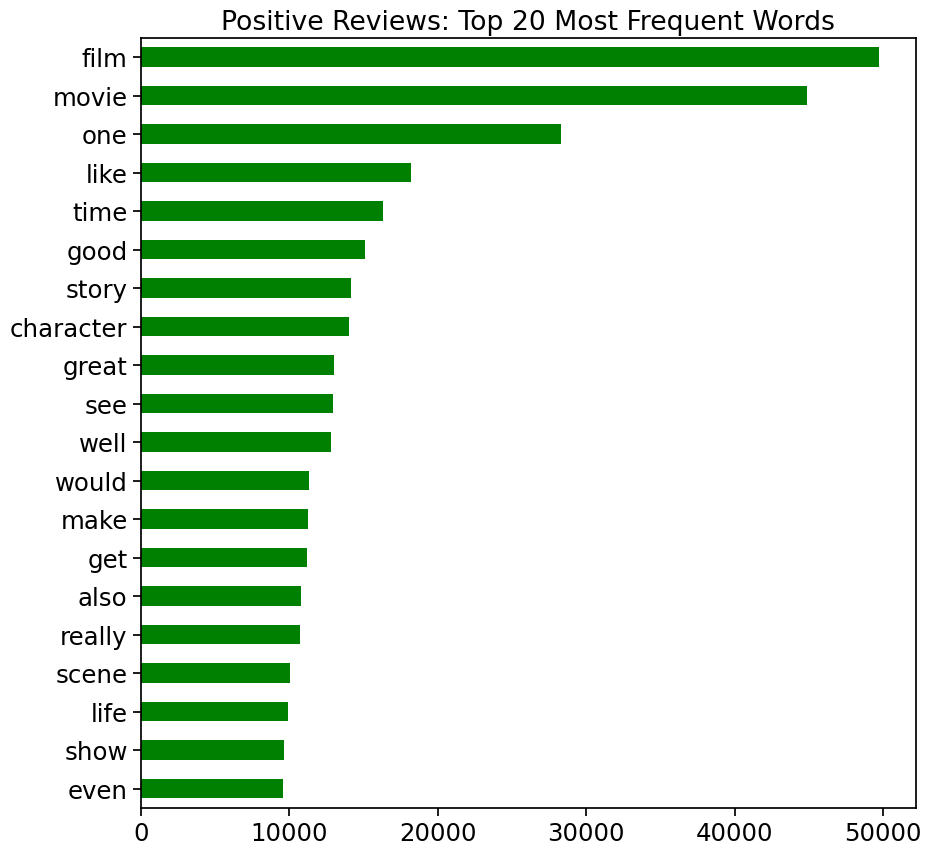

In [36]:
kamus_pos[:20].iloc[::-1].plot(kind = 'barh',figsize = (10,10), legend=False, color="green")

plt.title("Positive Reviews: Top 20 Most Frequent Words")
plt.xlabel("")
plt.ylabel("")
plt.show()

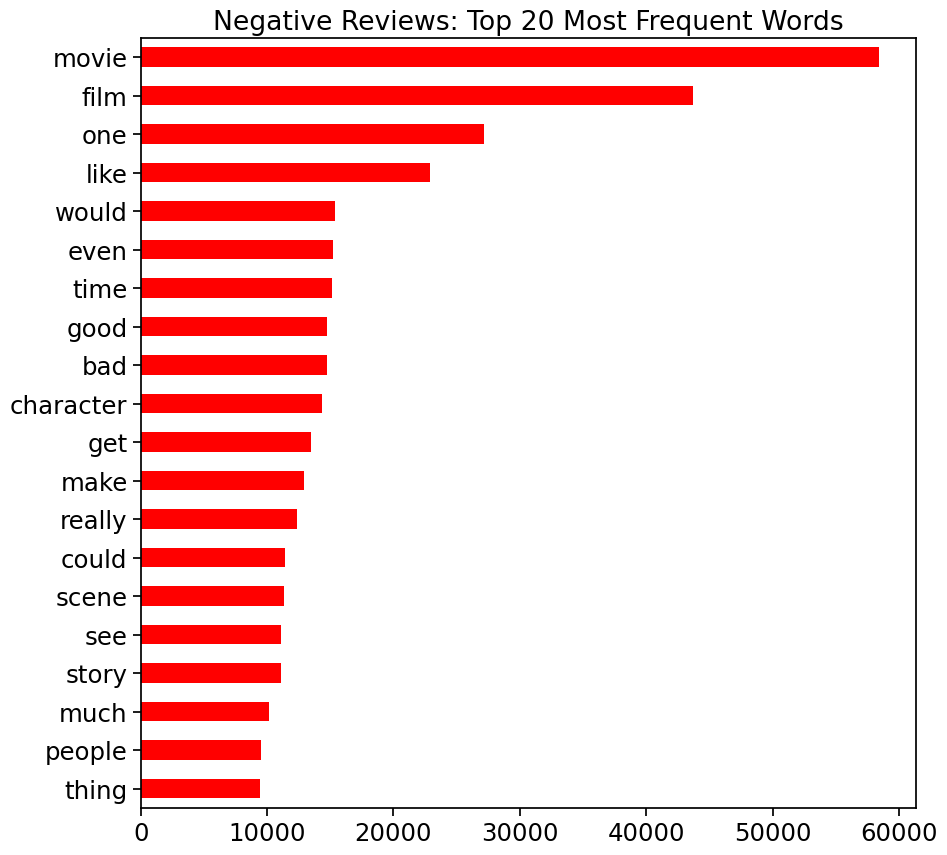

In [38]:
kamus_neg[:20].iloc[::-1].plot(kind = 'barh',figsize = (10,10), legend=False, color="red")

plt.title("Negative Reviews: Top 20 Most Frequent Words")
plt.xlabel("")
plt.ylabel("")
plt.show()

## **Insight**
- Dataset is content-centric. Focused on the movie and content itself (story, scene, characters)

### Positive Reviews
- Contains a lot of positive adjectives ("good", "great", "well")
- Praise narrative and emotions ("character", "life", "story", "show")

### Negative Reviews
- Have a very comparative tone ("even", "could", "would")
- Have a lot of nouns ("thing", "people"). Indicates vague language.

## **7. Word Cloud**

In [39]:
def plot_cloud(wordcloud):
    plt.figure(figsize=(20, 10))
    plt.imshow(wordcloud)
    plt.axis("off")

In [40]:
wordcloud = WordCloud(width = 3000, height = 2000, background_color='white', stopwords = stopwords.words('english'), contour_color='steelblue').generate(str(df['review_lemmatized']))

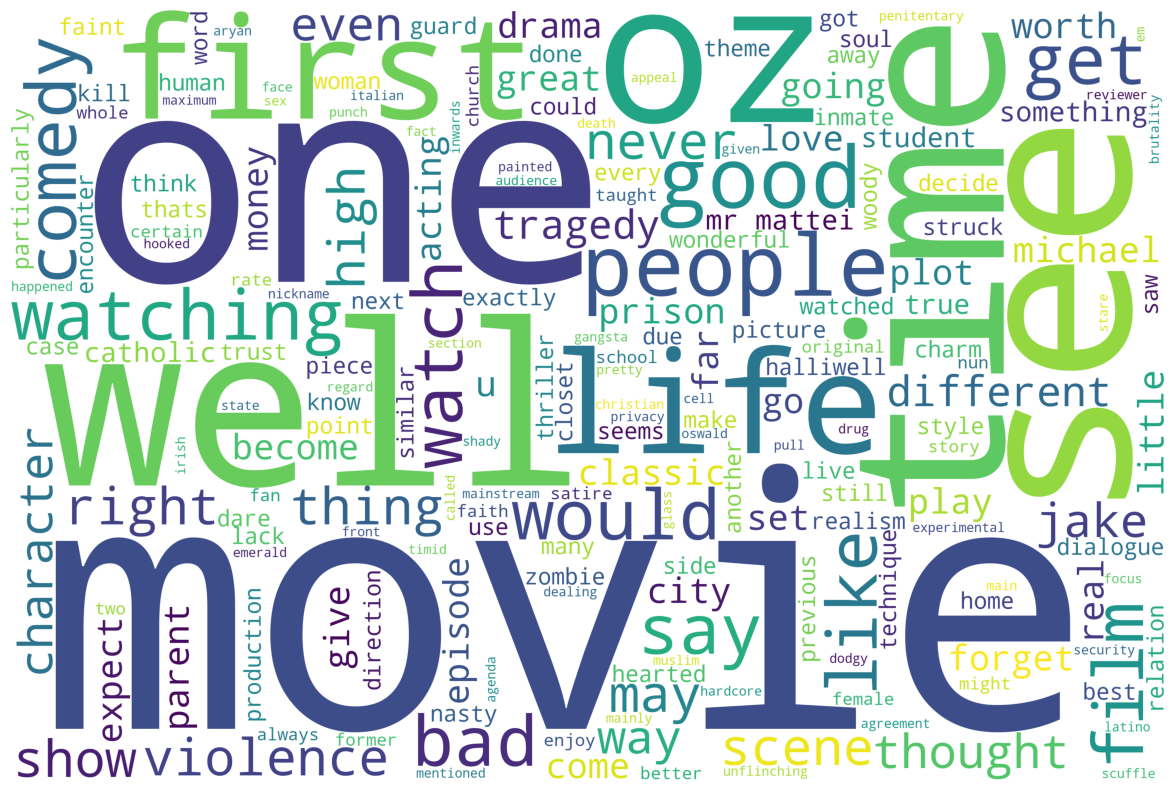

In [41]:
plot_cloud(wordcloud)

### **8.1. Word Cloud for Positive Reviews**

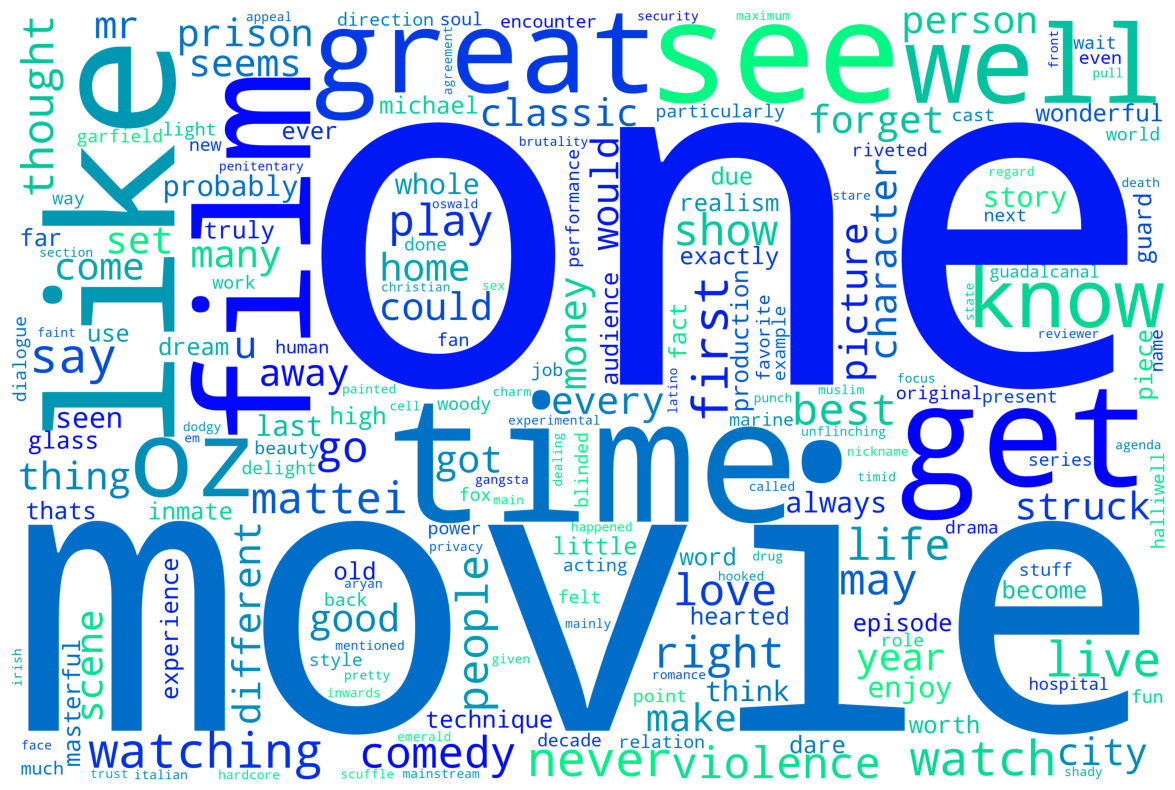

In [ ]:
wordcloud = WordCloud(width = 3000, height = 2000, random_state=1, background_color='white', colormap='winter', collocations=False, stopwords = stopwords.words('english')).generate(str(df[df['sentiment']=='positive']['review_lemmatized']))
plot_cloud(wordcloud)

### **8.2. Word Cloud for Negative Reviews**

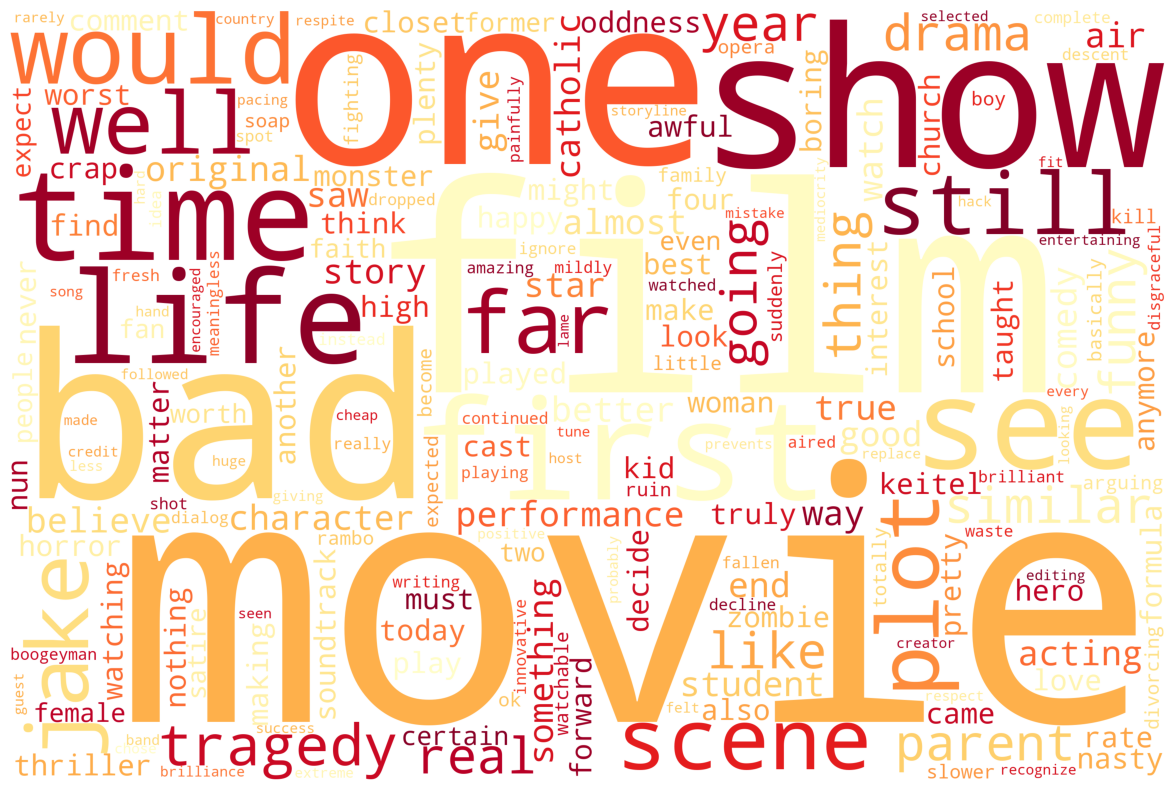

In [54]:
wordcloud = WordCloud(width = 3000, height = 2000, random_state=1, background_color='white', colormap='YlOrRd', collocations=False, stopwords = stopwords.words('english')).generate(str(df[df['sentiment']=='negative']['review_lemmatized']))
plot_cloud(wordcloud)

## **9. Length of Review per Sentiment**

In [55]:
df['length'] = df['review_prep1'].apply(len)

### **9.1. Length of Review for Positive Reviews**

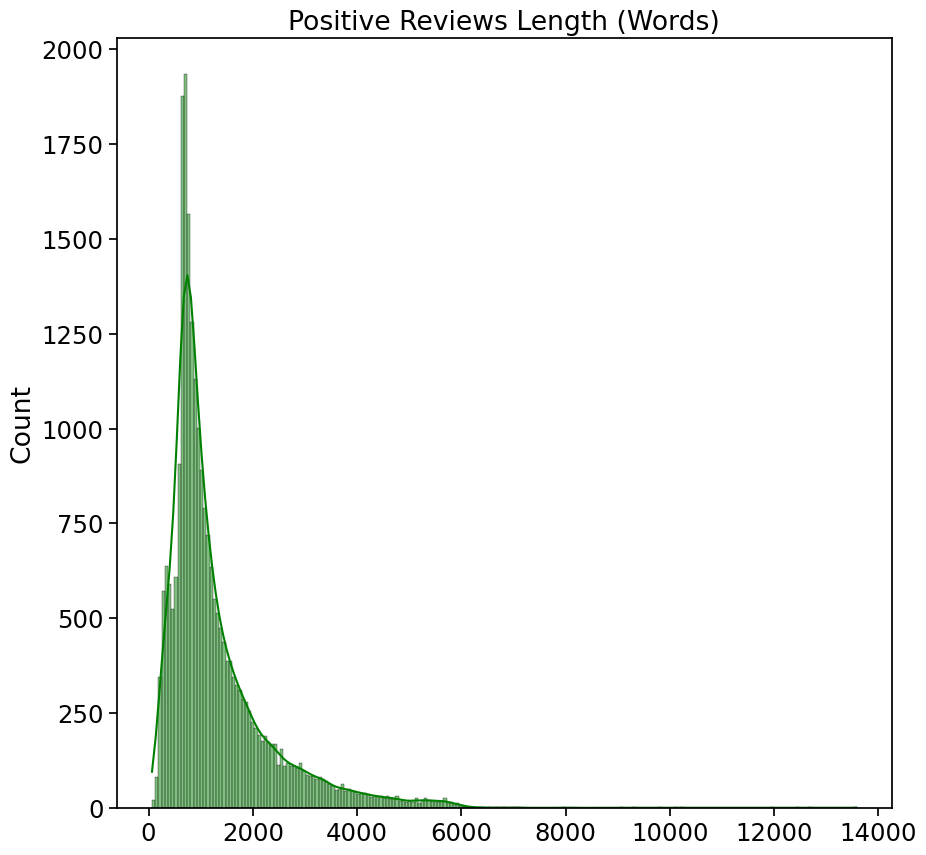

Positive reviews length median (Words): 951.0


In [91]:
plt.figure(figsize = (10,10))
df_review_pos = df[df['sentiment'] == 'positive']
sns.histplot(df_review_pos['length'], color="Green", kde=True)
plt.title('Positive Reviews Length (Words)')
plt.xlabel("")
plt.show()

print("Positive reviews length median (Words):", df_review_pos['length'].median())

### **9.2. Length of Review for Negative Reviews**

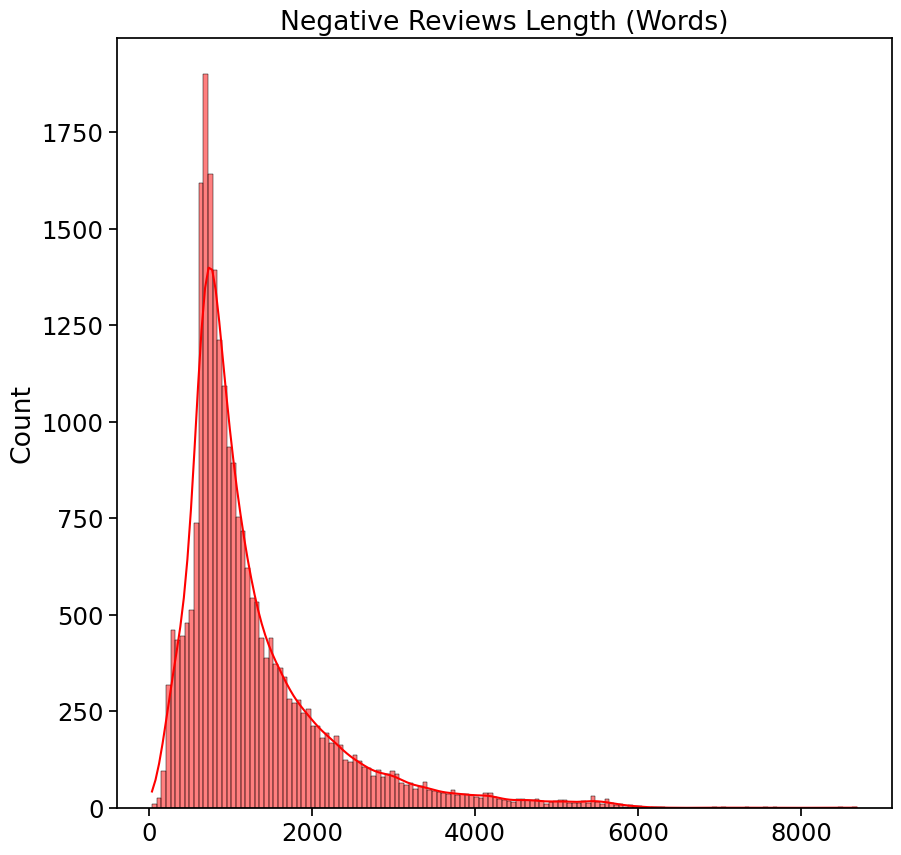

Negative reviews length median (Words): 956.0


In [90]:
plt.figure(figsize = (10,10))
df_review_neg = df[df['sentiment'] == 'negative']
sns.histplot(df_review_neg['length'], color="red", kde=True)
plt.title('Negative Reviews Length (Words)')
plt.xlabel("")
plt.show()

print("Negative reviews length median (Words):", df_review_neg['length'].median())


### **Insights:**
1. No **significant connection** to review length, both sentiments have identical lengths. Sentiment differentiation highlighted **more in vocab and phrase patterns**.
2. IMDB users are **thoughtful, dedicated**, movie-goers and reviewers, leaving **deliberate reviews** instead of short comments.

## **9. Common Phrases per Sentiment**
What are the most frequent phrases used for each sentiment?

In [ ]:
#Counting most common n-grams
def get_top_ngrams(corpus, ngram_range=(2,2), n=None):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    
    words_freq = [
        (word, sum_words[0, idx]) 
        for word, idx in vec.vocabulary_.items()
    ]
    sorted_words = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return sorted_words[:n]

In [76]:
top_pos_bigrams = get_top_ngrams(positive_reviews, ngram_range=(2,2), n=20)
top_neg_bigrams = get_top_ngrams(negative_reviews, ngram_range=(2,2), n=20)

In [77]:
pos_df = pd.DataFrame(top_pos_bigrams, columns=['phrase', 'freq'])
neg_df = pd.DataFrame(top_neg_bigrams, columns=['phrase', 'freq'])

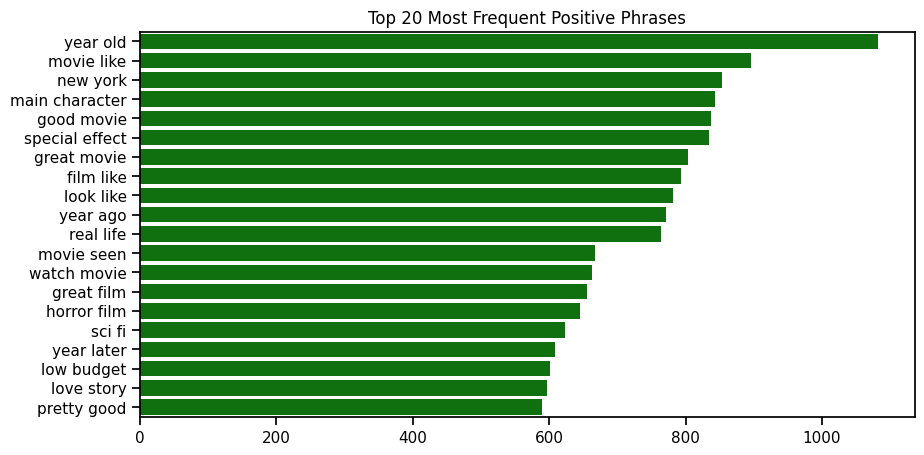

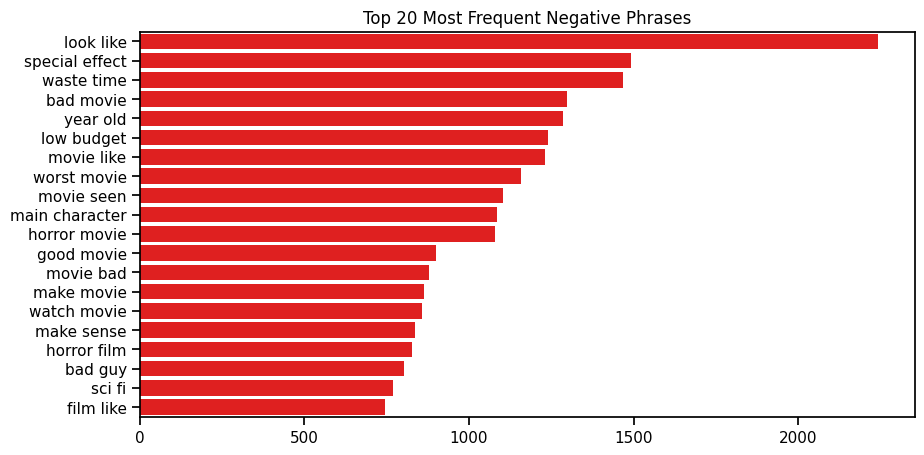

In [80]:
sns.set_context(context = 'notebook', font_scale = 1)

plt.figure(figsize=(10,5))
sns.barplot(x='freq', y='phrase', data=pos_df, color='green')
plt.title('Top 20 Most Frequent Positive Phrases')
plt.ylabel("")
plt.xlabel("")
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(x='freq', y='phrase', data=neg_df, color='red')
plt.title('Top 20 Most Frequent Negative Phrases')
plt.ylabel("")
plt.xlabel("")
plt.show()

## **Insight**
### Positive Reviews
- Refers a lot to the **setting** ("new york", "real life") and **narrative** ("main character")
- Have a lot of **positive reinforcement** ("great movie", "pretty good")
- Users use "year old" to rephrase and **summarize** the movie in their own language in the reviews ("25 year old Barry...", "A 29 year old who has...")
- "low budget" appearing indicates reviewers appreciate movies that are **made with constraints.**

### Negative Reviews
- Dominated by **technical and production-related** phrases ("special effect, low budget)
- Very **comparative** in nature ("look like", "movie like", "make movie")
- Strong **judgemental tone** ("bad movie", "worst movie", "waste time")
- "good movie" suggests usage of **contrastive phrasing** ("It would have been a good movie if...")

**General insight**: "low budget", "sci fi", and "horror movie" appears in both positive and negative reviews. This indicates that these genre of films are **polarizing**.

## **10. Extract Cleaned Data**

In [92]:
df_cleaned = df[['review_lemmatized', 'sentiment', 'text_length', 'length']]
df_cleaned.to_csv('IMDB_Dataset_Cleaned.csv', index=False)

In [93]:
pos_df["sentiment"] = "positive"
neg_df["sentiment"] = "negative"

combined_df = pd.concat([pos_df, neg_df])
combined_df.to_csv("common_phrases.csv", index=False)

## **11. Big Query Upload**

In [ ]:
credentials = service_account.Credentials.from_service_account_file(
    "path/to/credentials"
)

In [54]:
pandas_gbq.to_gbq(
    df_cleaned,
    destination_table='IMDB_Dataset_Cleaned.df_cleaned', 
    project_id='portofolio-modul-2-476009',
    credentials=credentials,
    if_exists='replace'
)

100%|██████████| 1/1 [00:00<00:00, 10180.35it/s]
